# Импорты библиотек

In [1]:
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
import phik
from scipy.stats import mannwhitneyu
from scipy.stats import chi2_contingency

# Чтение данных

In [2]:
_FILE_NAME = "videostreaming_platform.csv"

df = pd.read_csv(_FILE_NAME)

df.head()

,user_id,start_trial_date,city,device,source,favourite_genre,avg_min_watch_daily,number_of_days_logged,churn
0,d1b6ef34-1991-452a-8c39-c83c0d5805fe,2024-02-01,St Petersburg,ios,performance,drama,2.076642,4,1
1,f1bf2396-73d8-461e-a775-9f068bd99326,2024-02-01,Other,web,seo,criminal,5.101392,1,1
2,ec9fa0be-4bd8-4fe6-910a-e9e6d4bbba28,2024-02-01,Ufa,web,performance,criminal,2.906597,1,1
3,b0195e96-af2e-4ac3-8f60-26b8d862af84,2024-02-01,Moscow,smarttv,seo,thriller,2.702388,6,0
4,a208985a-7244-4291-8d38-64c8141e27b2,2024-02-01,Ufa,web,performance,thriller,10.237305,1,1


# Первичный анализ данных

**Вывод общей информации**

In [3]:
rows, cols = df.shape
print(f'Количество строк: {rows}, количество столбцов: {cols}\n')
print("============== Информация о датасете =============\n")
display(df.info())
print("============== Описательные статистики датасета =============\n")
display(df.describe())

Количество строк: 28000, количество столбцов: 9

============== Информация о датасете =============

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28000 entries, 0 to 27999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   user_id                28000 non-null  object 
 1   start_trial_date       28000 non-null  object 
 2   city                   27692 non-null  object 
 3   device                 28000 non-null  object 
 4   source                 28000 non-null  object 
 5   favourite_genre        20048 non-null  object 
 6   avg_min_watch_daily    28000 non-null  float64
 7   number_of_days_logged  28000 non-null  int64  
 8   churn                  28000 non-null  int64  
dtypes: float64(1), int64(2), object(6)
memory usage: 1.9+ MB


None

============== Описательные статистики датасета =============



,avg_min_watch_daily,number_of_days_logged,churn
count,28000.000000,28000.00000,28000.000000
mean,7.812663,1.88600,0.789286
std,7.739760,1.48293,0.407823
min,0.000181,1.00000,0.000000
25%,2.521966,1.00000,1.000000
50%,5.419012,1.00000,1.000000
75%,10.487946,2.00000,1.000000
max,80.072401,7.00000,1.000000


**Приведение start_trial_date к типу datetime**

In [4]:
df['start_trial_date'] = pd.to_datetime(df['start_trial_date'])

**Проверка на дубликаты**

In [5]:

rows_before = df.shape[0]

df.drop_duplicates()

rows_after = df.shape[0]

print('Нет удалённых дублированных строк') if rows_before == rows_after else print(f'Удалено дублей: {rows_before - rows_after}')

Нет удалённых дублированных строк


**Проверка дублей строк по user_id**

In [6]:
duplicated_by_id = df[df.duplicated(subset=['user_id'])]

print('Дубли строк по user_id', duplicated_by_id) if duplicated_by_id.size else print('Нет дублей строк по user_id')


Нет дублей строк по user_id


**Проверка колонок на пустые значения**

user_id: 0
start_trial_date: 0
city: 308
device: 0
source: 0
favourite_genre: 7952
avg_min_watch_daily: 0
number_of_days_logged: 0
churn: 0


<Axes: >

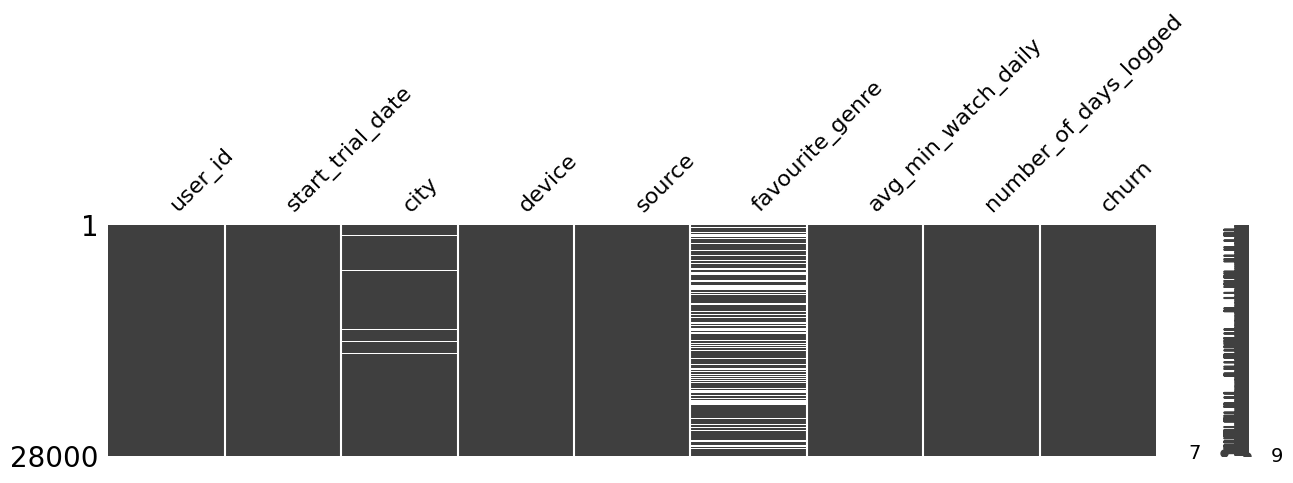

In [7]:
for column in df.columns:
    print(f'{column}: {df[column].isna().sum()}')

msno.matrix(df, figsize=(15, 3))

In [8]:
missing_summary = pd.DataFrame({
    'Количество': df.isna().sum(),
    'Пустых значений, %': (df.isna().sum() / len(df)) * 100
})

display(missing_summary)

,Количество,"Пустых значений, %"
user_id,0,0.0
start_trial_date,0,0.0
city,308,1.1
device,0,0.0
source,0,0.0
favourite_genre,7952,28.4
avg_min_watch_daily,0,0.0
number_of_days_logged,0,0.0
churn,0,0.0


**Первичный анализ времени просмтра**

In [9]:
# Предположим, что пользователь не может смотреть видео меньше 0.25 минуты
watch_daily_err = (df.avg_min_watch_daily <= 0.25).sum()

print(f'Строк с предположительно ошибочным временем просмотра: {watch_daily_err}, это {watch_daily_err/ (df.avg_min_watch_daily).sum() * 100} % от данных')

Строк с предположительно ошибочным временем просмотра: 817, это 0.3734779286816701 % от данных


**Так как данные по городу и по жанру значимы, то для дальнейшей корректной кодировки заменим их на значения None**

In [10]:
df['city'] = df['city'].fillna('None')
df['favourite_genre'] = df['favourite_genre'].fillna('None')

**Статистика столбцов**

In [11]:
print("========= Статистика по числовым колонкам ========")
display(df.describe())
print("====== Статистика по колонкам типа 'object' ======")
display(df.describe(include='object'))

========= Статистика по числовым колонкам ========


,start_trial_date,avg_min_watch_daily,number_of_days_logged,churn
count,28000,28000.000000,28000.00000,28000.000000
mean,2024-02-14 09:20:34.285714176,7.812663,1.88600,0.789286
min,2024-02-01 00:00:00,0.000181,1.00000,0.000000
25%,2024-02-07 00:00:00,2.521966,1.00000,1.000000
50%,2024-02-14 00:00:00,5.419012,1.00000,1.000000
75%,2024-02-21 00:00:00,10.487946,2.00000,1.000000
max,2024-02-28 00:00:00,80.072401,7.00000,1.000000
std,NaN,7.739760,1.48293,0.407823


====== Статистика по колонкам типа 'object' ======


,user_id,city,device,source,favourite_genre
count,28000,28000,28000,28000,28000
unique,28000,10,4,3,6
top,bdde7df5-3daf-4f5e-a102-7b2453d4a932,Moscow,web,performance,None
freq,1,8736,17752,14540,7952


**Описательная статистика для категориальных признаков**

In [12]:
def descriptive_statistics(df: pd.DataFrame, features: list[str]):
    
    result = {}

    for feature in features:

        unique_values = df[feature].unique()

        result[feature] = {
            'unique_values': unique_values.tolist(),
            'unique_values_count': len(unique_values),
            'unique_values_rate': df[feature].value_counts(normalize=True)
        }

    return result

def show_descriptive_statistics(statistics):
    for key, value in statistics.items():
        print(key, ': ')
        for k, v in value.items():
            print('  > ', k,':', str(v))
        print('-' * 40)

categorical_features = 'city,device,source,favourite_genre'.split(',')

statistics = descriptive_statistics(df, categorical_features) # type: ignore

show_descriptive_statistics(statistics)

city : 
  >  unique_values : ['St Petersburg', 'Other', 'Ufa', 'Moscow', 'Samara', 'Krasnodar', 'Yekaterinburg', 'Novosibirsk', 'Voronezh', 'None']
  >  unique_values_count : 10
  >  unique_values_rate : city
Moscow           0.312000
St Petersburg    0.160000
Other            0.095000
Krasnodar        0.091964
Novosibirsk      0.079036
Yekaterinburg    0.069000
Samara           0.067000
Ufa              0.059000
Voronezh         0.056000
None             0.011000
Name: proportion, dtype: float64
----------------------------------------
device : 
  >  unique_values : ['ios', 'web', 'smarttv', 'android']
  >  unique_values_count : 4
  >  unique_values_rate : device
web        0.634
smarttv    0.127
android    0.122
ios        0.117
Name: proportion, dtype: float64
----------------------------------------
source : 
  >  unique_values : ['performance', 'seo', 'organic']
  >  unique_values_count : 3
  >  unique_values_rate : source
performance    0.519286
organic        0.293000
seo       

> **Анализ датасета:**  
> - размер датасета - 8 столбцов и 28000 строк  
> - данные в формате `object`, `float64`, `int64`, привели `start_trial_date` к формату `datetime`
> - дубликатов по строкам или по ID нет
> - есть пропуски в `city` - 308 и в `favourite_genre` - 7952, которые заменены на 'None' для дальнейшей корректной кодировки
> 
> **Анализ столбцов:**  
> - данные представлены в промежутке с `01.02.2024` по `28.02.2024`
> - `avg_min_watch_daily` в промежутке от 0.000181 до 80.072401 минут, медиана 7.8 минут и среднее 5.4 отличнаются, что может говорить о выбросах. Минимальное время 0.000181 может говорить об ошибке в данных
> - `number_of_days_logged` от 1 до 7 дней, срденее - 1, медиана - 1.88, Что означает, что длительность триального периода вероятно - 7 дней, и большинство логируются только менее 2 дней
> - показатель отсутсвия покупки подписки `churn` - среднее 0.78, что говорит о 78% тех, кто не купил подписку после траильного периода
> - в `city` всего 10 значений: 'St Petersburg', 'Other', 'Ufa', 'Moscow', 'Samara', 'Krasnodar',
       'Yekaterinburg', 'Novosibirsk', 'Voronezh', 'None', самое популярное  - 'Moscow'
> - в `device` всего 4 значения: 'ios', 'web', 'smarttv', 'android', самое популярное  - 'web'
> - в `source` всего 3 значения: 'performance', 'seo', 'organic', самое популярное  - 'performance'
> - в `favourite_genre` всего 6 значений: 'drama', 'criminal', 'thriller', 'comedy', 'None', 'action', самое популярное - 'None'

# Чистка данных

**Удаление выбросов**

In [13]:
def remove_outliers_iqr(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    '''
    Функция удаляет выбросы по методу IQR
    '''
    for column in columns:
        q1 = df[column].quantile(0.25)
        q3 = df[column].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr 
        upper_bound = q3 + 1.5 * iqr
        df = df[ 
            (df[column] >= lower_bound) & (df[column] <= upper_bound)
            ]
        
    return df

numerals = ['avg_min_watch_daily', 'number_of_days_logged']

print(f'Строк до удаления выбросов: {df.shape[0]}')

df = remove_outliers_iqr(df, columns=numerals)

print(f'Строк после удаления выбросов: {df.shape[0]}')

Строк до удаления выбросов: 28000
Строк после удаления выбросов: 22993


## EDA

### Кодировка

Для всех категориальных столбцов применим метод One-Hot Encoding, так как это создавст новые столбцы с признаками, но при этом не будет значений 0, 1, 2... как в Label Encoding, что может привести к ошибки ML модели, так как наши данные равнозначны между собой, в отличие от, напрмиер категорий возраста

In [14]:
df_encoded = pd.get_dummies(
    df, columns=[
        'city',
        'device',
        'source',
        'favourite_genre'
    ], drop_first=False)

df_encoded = df_encoded.rename(columns={
    'city_Moscow': 'c_msk',
    'city_St Petersburg': 'c_spb', 
    'city_Novosibirsk': 'c_nsk',
    'city_Yekaterinburg': 'c_ekb',
    'city_Krasnodar': 'c_krd',
    'city_Samara': 'c_sam',
    'city_Voronezh': 'c_vrn',
    'city_Ufa': 'c_ufa',
    'city_Other': 'c_other',
    'city_None': 'c_none', 
    'device_web': 'd_web',
    'device_ios': 'd_ios',
    'device_android': 'd_android',
    'device_smarttv': 'd_smarttv',
    'source_performance': 's_perf',
    'source_organic': 's_org',
    'source_seo': 's_seo',
    'favourite_genre_drama': 'fg_drama',
    'favourite_genre_criminal': 'fg_criminal',
    'favourite_genre_thriller': 'fg_thriller',
    'favourite_genre_comedy': 'fg_comedy',
    'favourite_genre_action': 'fg_action',
    'favourite_genre_None': 'fg_none'
})

df = df_encoded.join(df[['city', 'device', 'source', 'favourite_genre']])

In [15]:
pd.set_option('display.max_columns', None)

In [16]:
display(
    df.sample(10),
    df.info()
)

<class 'pandas.core.frame.DataFrame'>
Index: 22993 entries, 1 to 27999
Data columns (total 32 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   user_id                22993 non-null  object        
 1   start_trial_date       22993 non-null  datetime64[ns]
 2   avg_min_watch_daily    22993 non-null  float64       
 3   number_of_days_logged  22993 non-null  int64         
 4   churn                  22993 non-null  int64         
 5   c_krd                  22993 non-null  bool          
 6   c_msk                  22993 non-null  bool          
 7   c_none                 22993 non-null  bool          
 8   c_nsk                  22993 non-null  bool          
 9   c_other                22993 non-null  bool          
 10  c_sam                  22993 non-null  bool          
 11  c_spb                  22993 non-null  bool          
 12  c_ufa                  22993 non-null  bool          
 13  c_vrn 

,user_id,start_trial_date,avg_min_watch_daily,number_of_days_logged,churn,c_krd,c_msk,c_none,c_nsk,c_other,c_sam,c_spb,c_ufa,c_vrn,c_ekb,d_android,d_ios,d_smarttv,d_web,s_org,s_perf,s_seo,fg_none,fg_action,fg_comedy,fg_criminal,fg_drama,fg_thriller,city,device,source,favourite_genre
15184,38933942-4741-41cb-a8de-1cb45a543e82,2024-02-15,0.277047,1,1,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True,False,False,False,True,False,False,False,False,Novosibirsk,android,organic,action
14203,c84adf1c-3a75-48e6-95c1-861ced9f3f0a,2024-02-14,19.772589,1,0,False,True,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,True,False,False,False,False,Moscow,ios,organic,action
1558,0a3eb582-6533-4a0a-8024-d937c90da7f8,2024-02-02,0.221365,1,1,True,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,True,False,Krasnodar,web,organic,drama
26353,3d07e109-1bb1-4990-b0d9-5a7b15fa6c2a,2024-02-27,13.968789,2,0,False,False,False,False,False,False,True,False,False,False,False,False,False,True,True,False,False,False,False,False,False,True,False,St Petersburg,web,organic,drama
6905,e0ca650d-7793-4629-96c5-1a813460e910,2024-02-07,6.532063,1,1,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,True,False,False,False,False,True,False,St Petersburg,web,seo,drama
25181,7ba90aef-ad86-4eb5-afac-5039707ec75c,2024-02-26,3.052825,2,1,False,False,False,True,False,False,False,False,False,False,False,False,False,True,True,False,False,True,False,False,False,False,False,Novosibirsk,web,organic,None
17159,fa2bafa2-68a7-4ea7-9ae0-c4ae40ca4624,2024-02-18,8.538164,1,1,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,True,False,False,True,False,False,False,Yekaterinburg,smarttv,seo,comedy
25706,6ef79437-f02b-4f98-841f-bb4a6a6f59e9,2024-02-26,0.937905,1,1,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,True,False,False,False,Novosibirsk,web,performance,comedy
23022,1a7a2c96-0872-45af-9c8a-f127161538a7,2024-02-24,2.006992,1,1,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,True,False,False,False,False,False,True,Ufa,web,seo,thriller
19270,0126f034-2948-4b35-9a6c-93eb3233347b,2024-02-20,7.496058,1,0,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,False,St Petersburg,ios,performance,None


None

### Оценка корреляции

interval columns not set, guessing: ['avg_min_watch_daily', 'number_of_days_logged', 'churn']


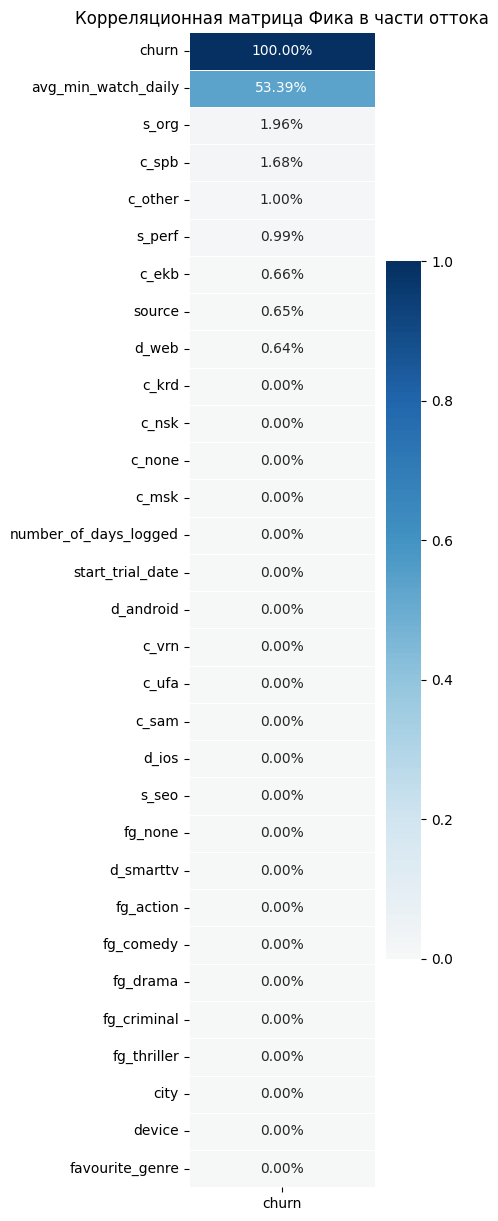

In [17]:
phik_corr_matrix = df.drop(columns='user_id').phik_matrix()
churn_phik_corr = phik_corr_matrix[['churn']].sort_values(by='churn', ascending=False)
plt.figure(figsize=(3, 15))
sns.heatmap(churn_phik_corr, annot=True, cmap='RdBu', center=0, fmt='.2%', linewidths=0.5)
plt.title('Корреляционная матрица Фика в части оттока')
plt.show()

### Исследование данных в колонках

#### `avg_min_watch_daily`

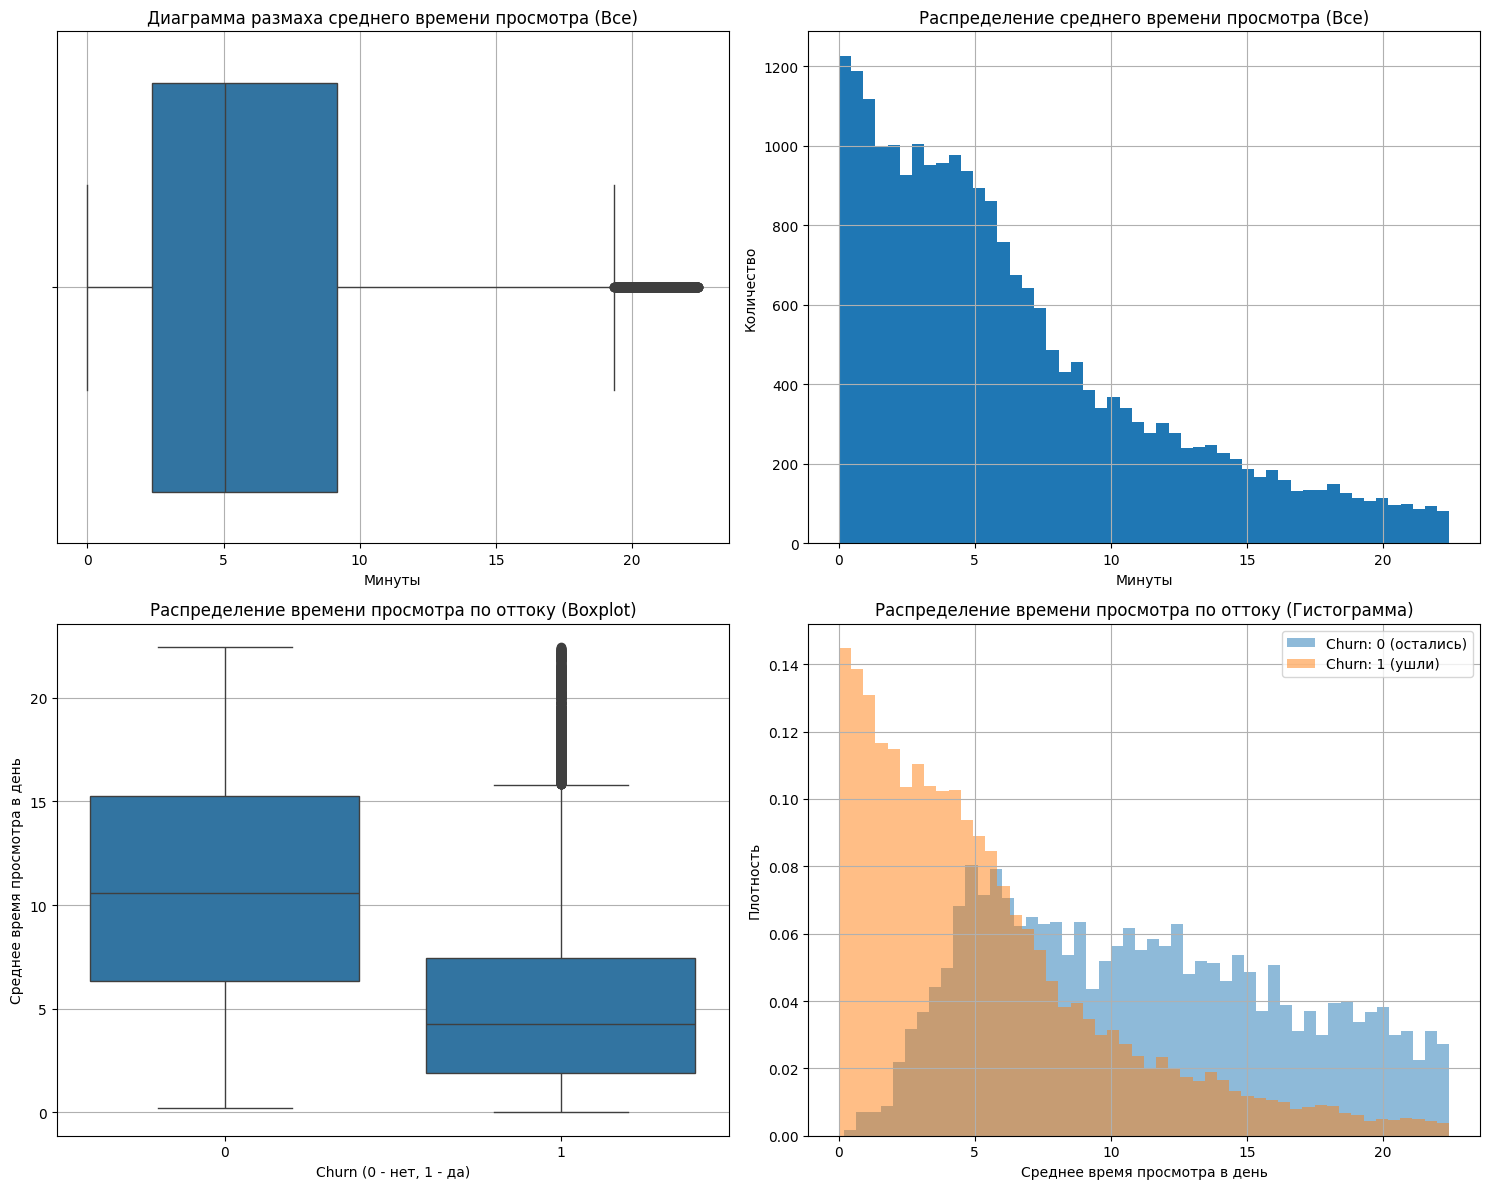

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12), gridspec_kw={'width_ratios': [1, 1]}) 

ax1 = axes[0, 0]  # Верхний левый
ax2 = axes[0, 1]  # Верхний правый
ax3 = axes[1, 0]  # Нижний левый
ax4 = axes[1, 1]  # Нижний правый

# 1. boxplot: ОБЩЕЕ распределение avg_min_watch_daily (без учета churn)
sns.boxplot(x=df['avg_min_watch_daily'], ax=ax1) # Используем ax1
ax1.set_title('Диаграмма размаха среднего времени просмотра (Все)')
ax1.set_xlabel('Минуты')
ax1.set_ylabel('') # Ящик с усами по умолчанию использует Y для размаха, X для значений
ax1.grid(True)

# 2. Гистограмма: ОБЩЕЕ распределение avg_min_watch_daily (без учета churn)
ax2.hist(df['avg_min_watch_daily'], bins=50)
ax2.set_title('Распределение среднего времени просмотра (Все)')
ax2.set_xlabel('Минуты')
ax2.set_ylabel('Количество')
ax2.grid(True)

# 3. boxplot: avg_min_watch_daily в разрезе churn
sns.boxplot(data=df, x='churn', y='avg_min_watch_daily', ax=ax3) # Используем ax3
ax3.set_title('Распределение времени просмотра по оттоку (Boxplot)')
ax3.set_xlabel('Churn (0 - нет, 1 - да)')
ax3.set_ylabel('Среднее время просмотра в день')
ax3.grid(True, axis='y')

# 4. Гистограмма: avg_min_watch_daily в разрезе churn (наложение)
churn_0_data = df[df['churn'] == 0]['avg_min_watch_daily']
churn_1_data = df[df['churn'] == 1]['avg_min_watch_daily']

ax4.hist(churn_0_data, bins=50, alpha=0.5, label='Churn: 0 (остались)', density=True)
ax4.hist(churn_1_data, bins=50, alpha=0.5, label='Churn: 1 (ушли)', density=True)
ax4.set_title('Распределение времени просмотра по оттоку (Гистограмма)')
ax4.set_xlabel('Среднее время просмотра в день')
ax4.set_ylabel('Плотность')
ax4.legend()
ax4.grid(True)

plt.tight_layout()
plt.show()

> видим что у отточной категории медиана среднего времени просомтра в 2 раза меньше в сравнении с теми, кто купил подсписку - 5 минут  
> среди тех, у кого среднее время более 8 минуты большинство купили подписку

#### `number_of_days_logged`

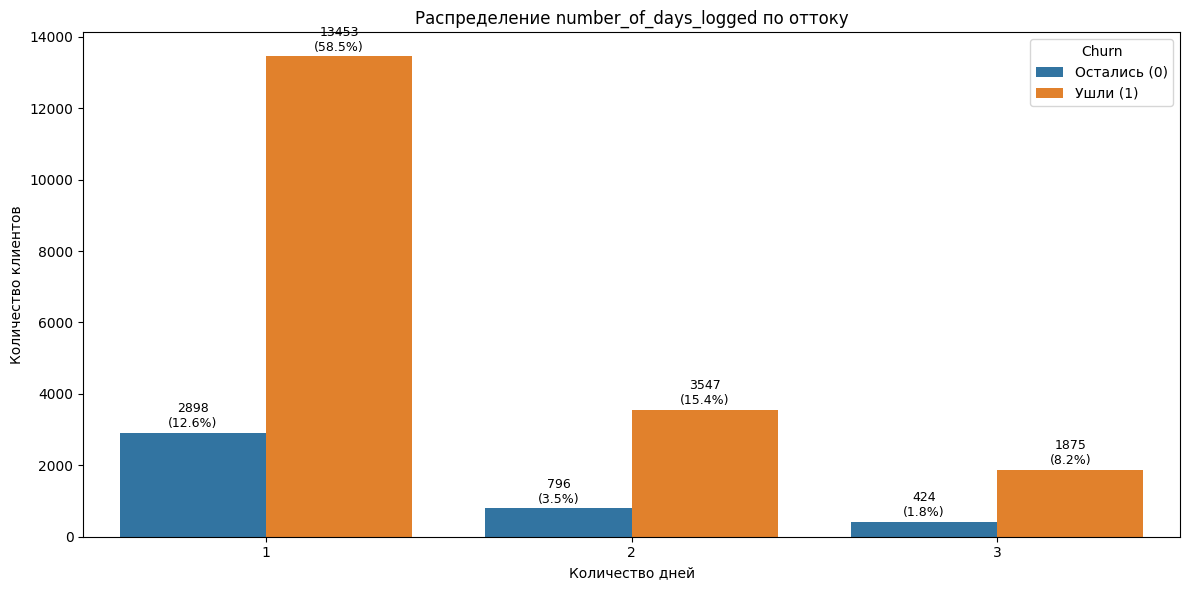

In [19]:
plt.figure(figsize=(12, 6))
ax = sns.countplot(x='number_of_days_logged', hue='churn', data=df)

plt.title('Распределение number_of_days_logged по оттоку')
plt.xlabel('Количество дней')
plt.ylabel('Количество клиентов')
plt.legend(title='Churn', labels=['Остались (0)', 'Ушли (1)']) 

# Добавляем аннотации (значения и проценты)
# Общее количество строк для расчета общего процента
total_count = len(df)

# Проходим по всем патчам (столбцам)
for p in ax.patches:
    height = p.get_height()
    if height > 0:  # Не аннотируем пустые столбцы
        percentage = (height / total_count) * 100
        ax.annotate(f'{int(height)}\n({percentage:.1f}%)',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', xytext=(0, 2), textcoords='offset points', fontsize=9)

plt.tight_layout() 
plt.show()

#### `start_trial_date`

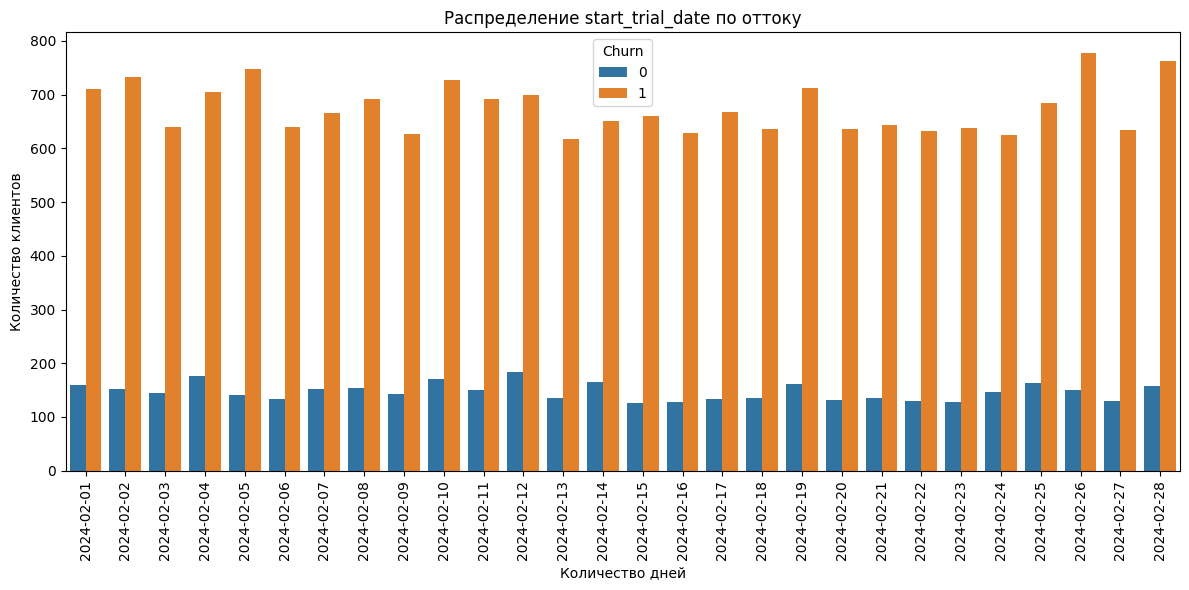

In [20]:
plt.figure(figsize=(12, 6))
sns.countplot(x='start_trial_date', hue='churn', data=df)

plt.title('Распределение start_trial_date по оттоку')
plt.xlabel('Количество дней')
plt.ylabel('Количество клиентов')
plt.legend(title='Churn')
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

> влияние даты начала на триальный период не выявлено, активность по дня примерно равномерная с небольшими вспелексами в выходные

#### `city`

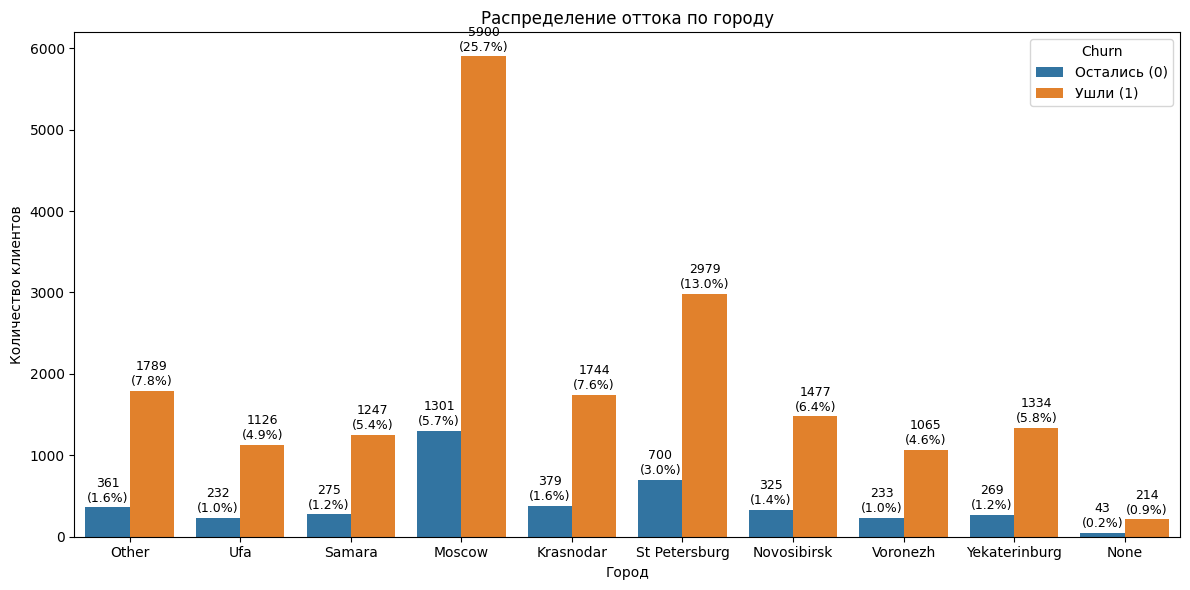

In [21]:
plt.figure(figsize=(12, 6))
ax = sns.countplot(x='city', hue='churn', data=df)

plt.title('Распределение оттока по городу')
plt.xlabel('Город')
plt.ylabel('Количество клиентов')
plt.legend(title='Churn', labels=['Остались (0)', 'Ушли (1)']) 

# Общее количество строк для расчета общего процента
total_count = len(df)

# Проходим по всем патчам (столбцам)
for p in ax.patches:
    height = p.get_height()
    if height > 0:  # Не аннотируем пустые столбцы
        percentage = (height / total_count) * 100
        ax.annotate(f'{int(height)}\n({percentage:.1f}%)',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', xytext=(0, 2), textcoords='offset points', fontsize=9)

plt.tight_layout() 
plt.show()

> на первый взгляд влияение города незначительно на отток, однако Москва и СПБ - самые большие когорты клиентов

#### `device`

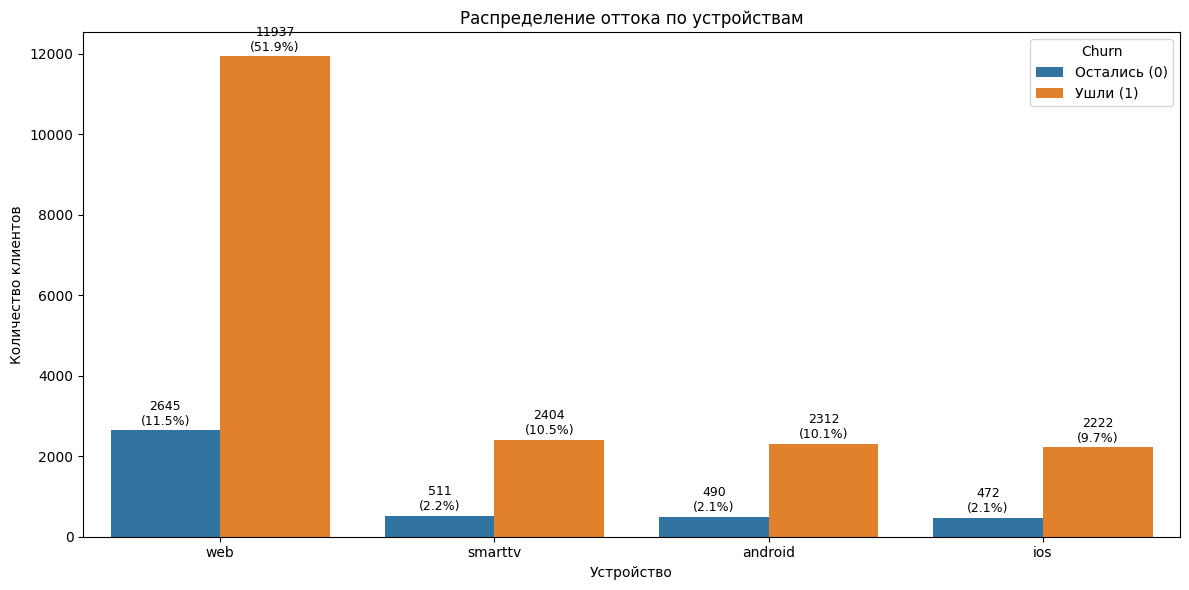

In [22]:
plt.figure(figsize=(12, 6))
ax = sns.countplot(x='device', hue='churn', data=df)

plt.title('Распределение оттока по устройствам')
plt.xlabel('Устройство')
plt.ylabel('Количество клиентов')
plt.legend(title='Churn', labels=['Остались (0)', 'Ушли (1)']) 

total_count = len(df)

for p in ax.patches:
    height = p.get_height()
    if height > 0:  
        percentage = (height / total_count) * 100
        ax.annotate(f'{int(height)}\n({percentage:.1f}%)',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', xytext=(0, 2), textcoords='offset points', fontsize=9)

plt.tight_layout() 
plt.show()

> визуально влияние устройства и оттока не прослеживается, но большая часть - это web

#### `source`	

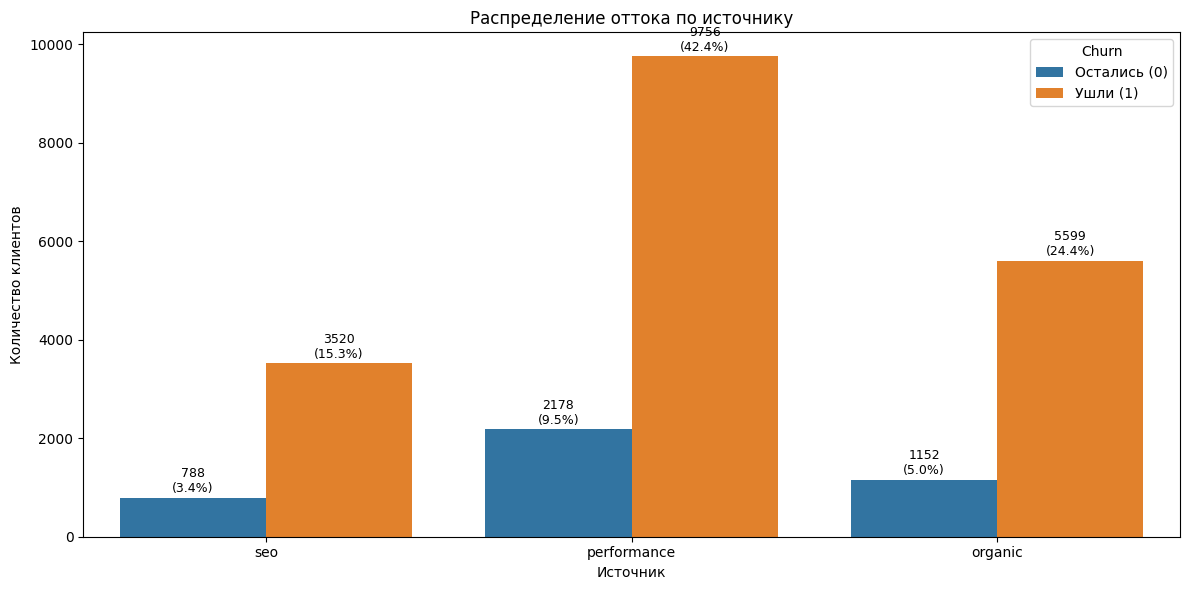

In [23]:
plt.figure(figsize=(12, 6))
ax = sns.countplot(x='source', hue='churn', data=df)

plt.title('Распределение оттока по источнику')
plt.xlabel('Источник')
plt.ylabel('Количество клиентов')
plt.legend(title='Churn', labels=['Остались (0)', 'Ушли (1)']) 

total_count = len(df)

for p in ax.patches:
    height = p.get_height()
    if height > 0:  
        percentage = (height / total_count) * 100
        ax.annotate(f'{int(height)}\n({percentage:.1f}%)',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', xytext=(0, 2), textcoords='offset points', fontsize=9)

plt.tight_layout() 
plt.show()

> влияние источника на отток не прослеживается

#### `favourite_genre`

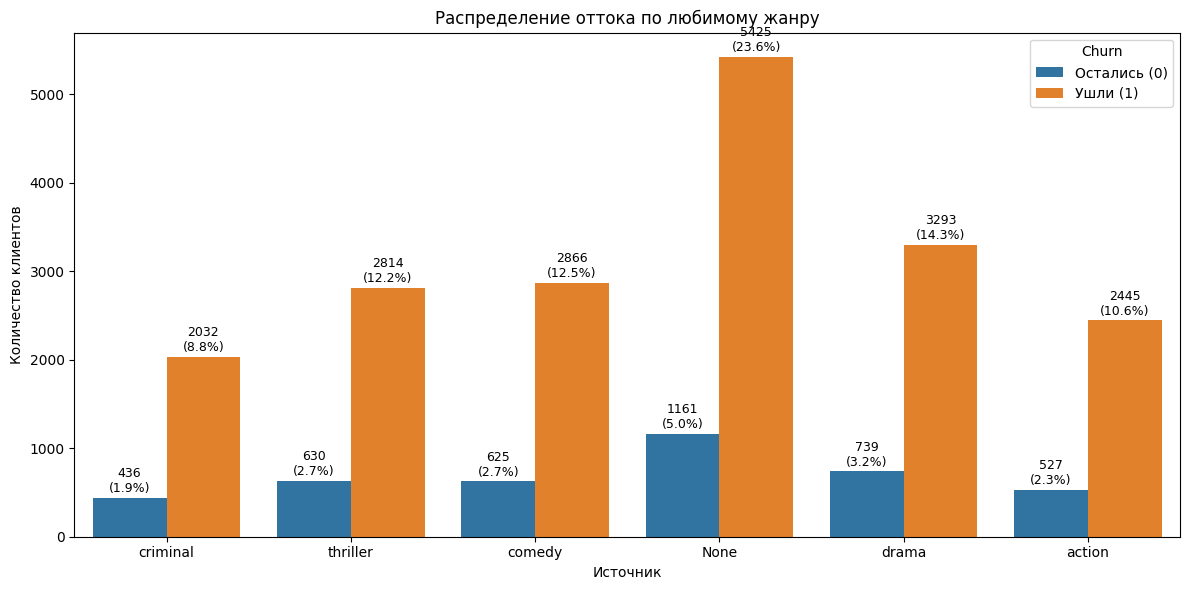

In [24]:
plt.figure(figsize=(12, 6))
ax = sns.countplot(x='favourite_genre', hue='churn', data=df)

plt.title('Распределение оттока по любимому жанру')
plt.xlabel('Источник')
plt.ylabel('Количество клиентов')
plt.legend(title='Churn', labels=['Остались (0)', 'Ушли (1)']) 

total_count = len(df)

for p in ax.patches:
    height = p.get_height()
    if height > 0:  
        percentage = (height / total_count) * 100
        ax.annotate(f'{int(height)}\n({percentage:.1f}%)',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', xytext=(0, 2), textcoords='offset points', fontsize=9)

plt.tight_layout() 
plt.show()

> - визуально можно отследить, что среди тех кто не указал любимый жанр - наибольшая категория оттока
> - при этом стоит также оценить корреляцию неуказания жанра и времени проведённого на сервисе, возможно человек ушёл, даже не успев воспользоваться, изучим это в след пункте

#### Дополнительная оценка корреляции

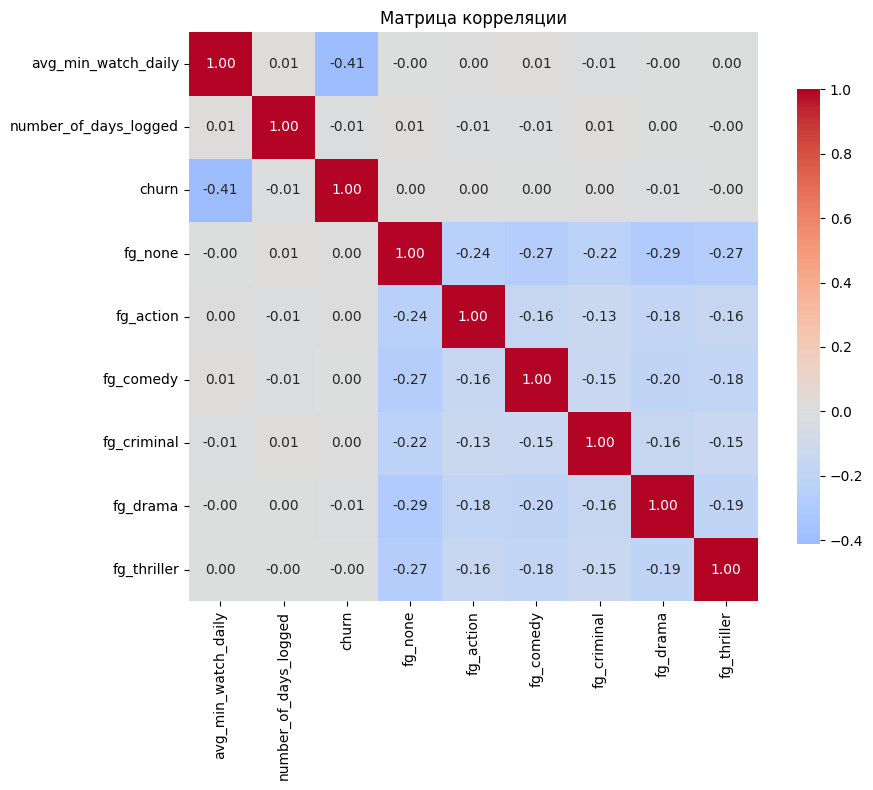

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Убедитесь, что названия столбцов соответствуют вашему датафрейму
columns_to_correlate = [
    'avg_min_watch_daily',
    'number_of_days_logged',
    'churn',
    'fg_none', 
    'fg_action',
    'fg_comedy',
    'fg_criminal',
    'fg_drama',
    'fg_thriller'
]

# Создаем подмножество DataFrame
df_subset = df[columns_to_correlate]

# Рассчитываем матрицу корреляции
correlation_matrix = df_subset.corr()

# Визуализируем
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    center=0,
    square=True,
    cbar_kws={"shrink": .8}
)
plt.title('Матрица корреляции')
plt.tight_layout()
plt.show()

> нет, всё же значимой корреляции между неуказанием жанра и временем проведённым на сервисе не удаётся найти

## Feature Engineering

In [26]:
import pandas as pd

# активен более 1 дня
df['is_active_more_than_1day'] = (df['number_of_days_logged'] > 1).astype(int)

# уровень активности (например, 1 день, 2-3 дня, 4-7 дней)
def categorize_activity(days):
    if days == 1:
        return '1'
    elif 2 <= days <= 3:
        return '2-3'
    elif 4 <= days <= 7:
        return '4-7'
    else:
        return '>7'
df['activity_level'] = df['number_of_days_logged'].apply(categorize_activity)

# плотность просмотра (суммарное время) 
df['total_watch_time'] = df['avg_min_watch_daily'] * df['number_of_days_logged']

# день недели начала пробного периода
df['trial_start_day_of_week'] = pd.to_datetime(df['start_trial_date']).dt.dayofweek

# бинарный признак для дня недели (например, выходной)
df['is_weekend'] = df['trial_start_day_of_week'].isin([6, 7]).astype(int)

# просмотр новых признаков
display(df[['is_active_more_than_1day', 'activity_level', 'total_watch_time', 'trial_start_day_of_week', 'is_weekend']].sample(10))

,is_active_more_than_1day,activity_level,total_watch_time,trial_start_day_of_week,is_weekend
10365,0,1,3.199227,6,1
26968,0,1,0.550686,2,0
1877,0,1,6.627866,4,0
18841,0,1,3.977338,0,0
27985,0,1,6.298719,2,0
1702,0,1,18.280854,4,0
11784,0,1,7.036879,0,0
17003,0,1,6.609845,5,0
2868,0,1,2.185014,5,0
14379,0,1,3.918202,3,0


# Гипотезы

## Формулировка гипотез о влиянии атрибутов на конверсию

Пусть:
- $Y = \text{conversion} \in \{0, 1\}$, где  
  $Y = 1$ — пользователь купил подписку,  
  $Y = 0$ — не купил.
- $X$ — числовые признаки (время просмотра, количество активных дней).
- $C$ — категориальные признаки (город, устройство, источник и т.д.).

Ниже приведён набор статистических гипотез, которые будут проверяться.

---

### **1. Влияние среднего времени просмотра (`avg_min_watch_daily`)**

**Нулевая гипотеза $H_0$:**
$$
P(Y = 1 \mid X_1 = x) = p_0 \quad \text{не зависит от } x.
$$

**Альтернативная гипотеза $H_1$:**
$$
\exists x_1, x_2:\; P(Y = 1 \mid X_1 = x_1) \neq P(Y = 1 \mid X_1 = x_2).
$$

---

### **2. Влияние количества активных дней (`number_of_days_logged`)**

**$H_0$:**
$$
P(Y = 1 \mid X_2 = k) = p_0 \quad \text{для всех } k.
$$

**$H_1$:**
$$
\exists k_1, k_2:\; P(Y = 1 \mid X_2 = k_1) \neq P(Y = 1 \mid X_2 = k_2).
$$

---

### **3. Влияние города регистрации (`city`)**

**$H_0$:**
$$
P(Y = 1 \mid C_1 = c_1) = P(Y = 1 \mid C_1 = c_2) = \dots
$$

**$H_1$:**
$$
\exists c_i, c_j:\; P(Y = 1 \mid C_1 = c_i) \neq P(Y = 1 \mid C_1 = c_j).
$$

---

### **4. Влияние устройства регистрации (`device`)**

**$H_0$:**
$$
P(Y = 1 \mid C_2 = d_1) = P(Y = 1 \mid C_2 = d_2) = \dots
$$

**$H_1$:**
$$
\exists d_i, d_j:\; P(Y = 1 \mid C_2 = d_i) \neq P(Y = 1 \mid C_2 = d_j).
$$

---

### **5. Влияние источника трафика (`source`)**

**$H_0$:**
$$
P(Y = 1 \mid C_3 = s_1) = P(Y = 1 \mid C_3 = s_2) = \dots
$$

**$H_1$:**
$$
\exists s_i, s_j:\; P(Y = 1 \mid C_3 = s_i) \neq P(Y = 1 \mid C_3 = s_j).
$$

---

### **6. Влияние выбранного жанра (`favourite_genre`)**

**$H_0$:**
$$
P(Y = 1 \mid C_4 = g_1) = P(Y = 1 \mid C_4 = g_2) = \dots
$$

**$H_1$:**
$$
\exists g_i, g_j:\; P(Y = 1 \mid C_4 = g_i) \neq P(Y = 1 \mid C_4 = g_j).
$$

---

### **7. Влияние самого факта указания жанра**

Вводим бинарную переменную:
$$
Z = 
\begin{cases}
1,& \text{если жанр указан},\\
0,& \text{если жанр не указан}.
\end{cases}
$$

**$H_0$:**
$$
P(Y = 1 \mid Z = 0) = P(Y = 1 \mid Z = 1).
$$

**$H_1$:**
$$
P(Y = 1 \mid Z = 0) \neq P(Y = 1 \mid Z = 1).
$$

---

### **8. Влияние даты начала триала (`start_trial_date`)**

(когортный анализ)

**$H_0$:**
$$
P(Y = 1 \mid C_5 = t_1) = P(Y = 1 \mid C_5 = t_2) = \dots
$$

**$H_1$:**
$$
\exists t_i, t_j:\; P(Y = 1 \mid C_5 = t_i) \neq P(Y = 1 \mid C_5 = t_j).
$$

---

### **Итог**

Мы сформировали полный набор гипотез, которые описывают влияние каждого признака на вероятность покупки пользователем подписки. Каждая гипотеза будет проверена статистически (хи-квадрат, корреляция, квантильный анализ, логистическая регрессия).

## План статистической проверки гипотез

После формулировки гипотез необходимо определить корректные методы их проверки.  
Выбор теста зависит от типа признака (числовой / категориальный) и распределения данных.

---

### **1. Проверка влияния среднего времени просмотра (`avg_min_watch_daily`)**

Тип признака: числовой (непрерывный).  
Тип ответа: бинарный (0/1).

**Инструменты проверки:**

1. **Корреляция Пирсона между `avg_min_watch_daily` и `conversion`**  
   - Проверяет линейную связь между признаками.  
   - Значимое отклонение коэффициента от 0 → основание отвергнуть $H_0$.

2. **Квантильный анализ конверсии**  
   - Разбиваем пользователей на группы по времени просмотра.  
   - Если конверсия изменяется монотонно → свидетельство влияния.

3. **Тест разницы долей между квантилями (z-test proportion)**  
   - Проверяет, различаются ли конверсии между низкими и высокими квантилями.

---

### **2. Проверка влияния числа активных дней (`number_of_days_logged`)**

Тип признака: числовой, дискретный.

**Инструменты:**

1. **Корреляция Пирсона между `number_of_days_logged` и `conversion`**.  
2. **Сравнение конверсии между значениями (например, 1 vs 7 дней) с помощью z-test пропорций**.  
3. **Логистическая регрессия** (в расширенном исследовании).

---

### **3. Проверка влияния города (`city`)**

Тип признака: категориальный, >2 значений.

**Инструмент:**  
**Хи-квадрат тест независимости (χ² test of independence)**.

- Строим таблицу сопряжённости `city × conversion`.  
- Вычисляем χ² и p-value.  
- Если $p < \alpha$ → отклоняем $H_0$.

---

### **4. Проверка влияния устройства (`device`)**

Тип: категориальный, малое количество значений.

**Инструмент:**  
**Хи-квадрат тест независимости.**

Применение аналогично проверке по городу.

---

### **5. Проверка влияния источника трафика (`source`)**

Тип: категориальный.

**Инструмент:**
- **Хи-квадрат тест независимости.**
- При необходимости — post-hoc тесты для парных сравнений долей.

---

### **6. Проверка влияния жанра (`favourite_genre`)**

Тип: категориальный, много уровней, много пропусков.

**Инструменты:**

1. **Хи-квадрат тест независимости** — сравнение распределений.  
2. **Анализ пропусков как отдельной категории**:
   - создаём признак `genre_filled` (0/1),  
   - сравниваем конверсию через z-test разницы долей.

---

### **7. Проверка влияния факта указания жанра**

Тип: бинарный (жанр указан / не указан).

**Инструмент:**  
**z-test пропорций (test for difference in proportions)**.

Проверяет равенство двух вероятностей:
$$
P(Y=1 \mid Z=1) \quad \text{vs} \quad P(Y=1 \mid Z=0).
$$

---

### **8. Проверка влияния даты старта триала (`start_trial_date`)**

Тип: временной (дата → когорта).

**Инструменты:**

1. **Группировка по неделям или дням → χ² тест между когортами**.  
2. **Проверка тренда**  
   если даты упорядочены.

---

### **Итоговый план**

Каждый признак будет проверен статистически корректным методом:

| Признак                    | Тип           | Метод проверки                              |
|----------------------------|---------------|----------------------------------------------|
| avg_min_watch_daily        | числовой      | Пирсон, квантильный анализ, z-test           |
| number_of_days_logged      | числовой      | Пирсон, сравнение долей                      |
| city                       | категориальный| χ² тест                                      |
| device                     | категориальный| χ² тест                                      |
| source                     | категориальный| χ² тест                                      |
| favourite_genre            | категориальный| χ² тест                                      |
| genre_filled (0/1)         | бинарный      | z-test пропорций                             |
| start_trial_date (когорты) | временной     | χ² по когортам                               |

Все выводы будут формулироваться через p-value при уровне значимости  
$$
\alpha = 0.05.
$$